In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_insurance_data
from src.eda_utils import calculate_loss_ratio, plot_numerical_distributions, plot_categorical_distributions, detect_outliers

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [45]:
# Load the data
file_path = Path("data") / "insurance_data.csv"
df = pd.read_csv(file_path, sep='|', on_bad_lines='skip', encoding='utf-8')
print(f"Data loaded! Shape: {df.shape}")
print(f"Columns: {list(df.columns)[:10]}...")
df.head(3)

C:\Users\stsio\AppData\Local\Temp\ipykernel_2580\2057434322.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|', on_bad_lines='skip', encoding='utf-8')


Data loaded! Shape: (1000098, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType']...


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [46]:
# Convert to proper data types
df['TotalPremium'] = pd.to_numeric(df['TotalPremium'], errors='coerce')
df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

print("Data types converted!")
print(f"Premium range: {df['TotalPremium'].min():.2f} - {df['TotalPremium'].max():.2f}")
print(f"Claims range: {df['TotalClaims'].min():.2f} - {df['TotalClaims'].max():.2f}")

Data types converted!
Premium range: -782.58 - 65282.60
Claims range: -12002.41 - 393092.11


In [47]:
# Calculate metrics
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium
overall_margin = total_premium - total_claims

print("=" * 50)
print("PORTFOLIO SUMMARY")
print("=" * 50)
print(f"Total Premium: R{total_premium:,.2f}")
print(f"Total Claims: R{total_claims:,.2f}")
print(f"Loss Ratio: {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
print(f"Margin: R{overall_margin:,.2f}")

PORTFOLIO SUMMARY
Total Premium: R61,911,562.70
Total Claims: R64,867,546.17
Loss Ratio: 1.0477 (104.77%)
Margin: R-2,955,983.47


In [48]:
# Calculate metrics
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium
overall_margin = total_premium - total_claims

print("=" * 50)
print("PORTFOLIO SUMMARY")
print("=" * 50)
print(f"Total Premium: R{total_premium:,.2f}")
print(f"Total Claims: R{total_claims:,.2f}")
print(f"Loss Ratio: {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
print(f"Margin: R{overall_margin:,.2f}")

PORTFOLIO SUMMARY
Total Premium: R61,911,562.70
Total Claims: R64,867,546.17
Loss Ratio: 1.0477 (104.77%)
Margin: R-2,955,983.47


In [49]:
# Missing values analysis
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("COLUMNS WITH MISSING VALUES")
print(missing_df.head(15))
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Total cells: {df.shape[0] * df.shape[1]:,}")
print(f"Missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

COLUMNS WITH MISSING VALUES
                         Missing Count   Missing %
NumberOfVehiclesInFleet        1000098  100.000000
CrossBorder                     999400   99.930207
CustomValueEstimate             779642   77.956560
WrittenOff                      641901   64.183810
Converted                       641901   64.183810
Rebuilt                         641901   64.183810
NewVehicle                      153295   15.327998
Bank                            145961   14.594670
AccountType                      40232    4.022806
Gender                            9536    0.953507
MaritalStatus                     8259    0.825819
mmcode                             552    0.055195
VehicleType                        552    0.055195
make                               552    0.055195
VehicleIntroDate                   552    0.055195

Total missing values: 5,067,648
Total cells: 52,005,096
Missing percentage: 9.74%


OUTLIER DETECTION
TotalClaims - Outliers: 2793 (0.28%)
TotalPremium - Outliers: 209042 (20.90%)


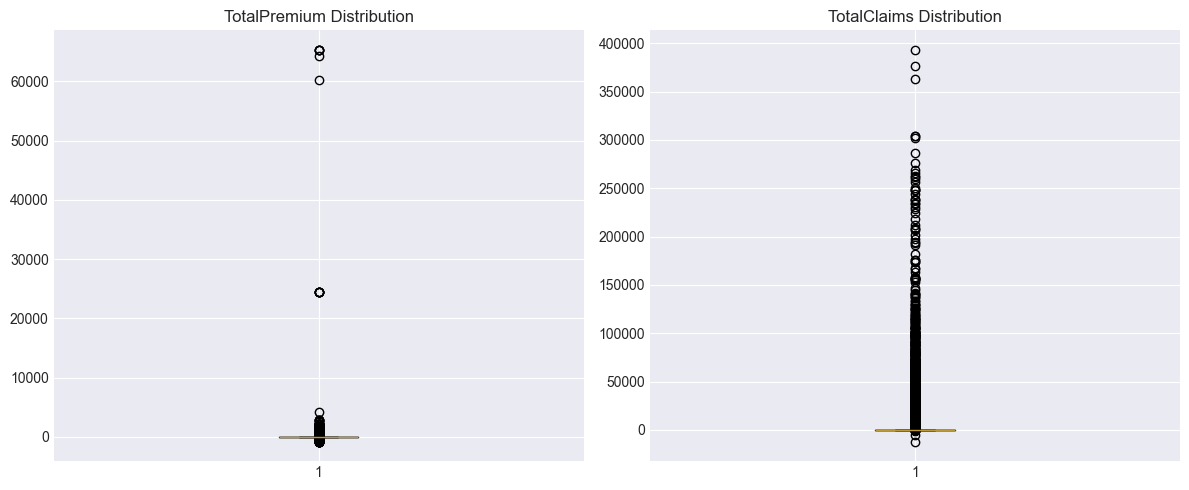

In [50]:
# Detect outliers
outliers_claims, lower_claims, upper_claims = detect_outliers(df, 'TotalClaims')
outliers_premium, lower_premium, upper_premium = detect_outliers(df, 'TotalPremium')

print("OUTLIER DETECTION")
print(f"TotalClaims - Outliers: {len(outliers_claims)} ({len(outliers_claims)/len(df)*100:.2f}%)")
print(f"TotalPremium - Outliers: {len(outliers_premium)} ({len(outliers_premium)/len(df)*100:.2f}%)")

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df['TotalPremium'].dropna())
axes[0].set_title('TotalPremium Distribution')
axes[1].boxplot(df['TotalClaims'].dropna())
axes[1].set_title('TotalClaims Distribution')
plt.tight_layout()
plt.show()

In [51]:
# Vehicle makes analysis
print("VEHICLE MAKES - CLAIM ANALYSIS")
print("=" * 50)

vehicle_claims = df.groupby('make').agg({
    'TotalClaims': 'mean',
    'TotalPremium': 'mean',
    'PolicyID': 'count'
}).rename(columns={'PolicyID': 'Count'})
vehicle_claims = vehicle_claims[vehicle_claims['Count'] >= 100]
vehicle_claims['LossRatio'] = vehicle_claims['TotalClaims'] / vehicle_claims['TotalPremium']

print("\nTop 5 HIGHEST average claims:")
print(vehicle_claims.nlargest(5, 'TotalClaims')[['TotalClaims', 'Count', 'LossRatio']])

print("\nTop 5 LOWEST average claims:")
print(vehicle_claims.nsmallest(5, 'TotalClaims')[['TotalClaims', 'Count', 'LossRatio']])

VEHICLE MAKES - CLAIM ANALYSIS

Top 5 HIGHEST average claims:
                                     TotalClaims  Count  LossRatio
make                                                              
SUZUKI                                419.634546    408   6.338194
JMC                                   191.684795    120   4.081449
HYUNDAI                               174.215195   2602   3.989840
AUDI                                  137.843083   7407   2.713456
POLARSUN                              134.044800    934   3.051418

Top 5 LOWEST average claims:
                                     TotalClaims  Count  LossRatio
make                                                              
CHERY                                        0.0    361        0.0
CITROEN                                      0.0    561        0.0
FORD                                         0.0    242        0.0
GEELY                                        0.0    108        0.0
HINO                                 

In [52]:
# First, check what 'make' values actually exist
print("AVAILABLE VEHICLE MAKES (first 20)")
print("=" * 50)
unique_makes = df['make'].dropna().unique()
print(sorted(unique_makes)[:20])
print(f"\nTotal unique makes: {len(unique_makes)}")

# Find Suzuki if it exists with different spelling
suzuki_variants = [m for m in unique_makes if 'SUZUKI' in str(m).upper()]
print(f"\nSuzuki variants found: {suzuki_variants}")

# If Suzuki exists, analyze it
if len(suzuki_variants) > 0:
    suzuki_make = suzuki_variants[0]
    suzuki = df[df['make'] == suzuki_make]
    
    print("\n" + "=" * 50)
    print(f"INVESTIGATING {suzuki_make} LOSS RATIO")
    print("=" * 50)
    print(f"Number of policies: {len(suzuki)}")
    
    if len(suzuki) > 0:
        print(f"Average Premium: R{suzuki['TotalPremium'].mean():.2f}")
        print(f"Average Claims: R{suzuki['TotalClaims'].mean():.2f}")
        print(f"Median Premium: R{suzuki['TotalPremium'].median():.2f}")
        print(f"Median Claims: R{suzuki['TotalClaims'].median():.2f}")
        
        # Check if claims are much higher than premium
        suzuki_high_claims = suzuki[suzuki['TotalClaims'] > suzuki['TotalPremium']]
        print(f"\nPolicies with Claims > Premium: {len(suzuki_high_claims)}")
        if len(suzuki) > 0:
            print(f"Percentage: {len(suzuki_high_claims)/len(suzuki)*100:.1f}%")
else:
    print("\nNo Suzuki vehicles found in dataset. Let's check the top makes instead.")

# Check top 10 makes by volume
print("\n" + "=" * 50)
print("TOP 10 MAKES BY NUMBER OF POLICIES")
print("=" * 50)
top_makes = df['make'].value_counts().head(10)
for make, count in top_makes.items():
    make_data = df[df['make'] == make]
    avg_premium = make_data['TotalPremium'].mean()
    avg_claims = make_data['TotalClaims'].mean()
    loss_ratio = avg_claims / avg_premium if avg_premium > 0 else 0
    print(f"{make}: {count} policies, Loss Ratio: {loss_ratio:.2f}")

AVAILABLE VEHICLE MAKES (first 20)
['AUDI', 'B.A.W', 'BMW', 'C.A.M', 'CHERY                              ', 'CHEVROLET', 'CITROEN                            ', 'CMC', 'DAIHATSU', 'FIAT', 'FORD', 'FORD                               ', 'FOTON', 'GEELY                              ', 'GOLDEN JOURNEY', 'HINO', 'HONDA', 'HUMMER', 'HYUNDAI', 'IVECO']

Total unique makes: 46

Suzuki variants found: ['SUZUKI                             ']

INVESTIGATING SUZUKI                              LOSS RATIO
Number of policies: 408
Average Premium: R66.21
Average Claims: R419.63
Median Premium: R1.32
Median Claims: R0.00

Policies with Claims > Premium: 7
Percentage: 1.7%

TOP 10 MAKES BY NUMBER OF POLICIES
TOYOTA: 813280 policies, Loss Ratio: 1.04
MERCEDES-BENZ: 41940 policies, Loss Ratio: 1.06
CMC: 21624 policies, Loss Ratio: 1.38
VOLKSWAGEN: 20929 policies, Loss Ratio: 1.30
C.A.M: 16171 policies, Loss Ratio: 1.15
GOLDEN JOURNEY: 14462 policies, Loss Ratio: 0.85
NISSAN/DATSUN                      : 1

In [53]:
print("=" * 50)
print("DATA SCALE ANALYSIS")
print("=" * 50)

# Check premium distribution
print("\nTotalPremium Statistics:")
print(df['TotalPremium'].describe())

print("\nTotalClaims Statistics:")
print(df['TotalClaims'].describe())

# Check relationship
df['Claims_Greater_Than_Premium'] = df['TotalClaims'] > df['TotalPremium']
pct_greater = df['Claims_Greater_Than_Premium'].mean() * 100
print(f"\nPercentage of policies where Claims > Premium: {pct_greater:.2f}%")

# Look at sample where claims > premium
print("\nSample of policies with Claims > Premium:")
sample_high = df[df['TotalClaims'] > df['TotalPremium']][['make', 'TotalPremium', 'TotalClaims']].head(10)
print(sample_high.to_string(index=False))

# Look at sample where claims are reasonable
print("\nSample of policies with normal claims:")
sample_normal = df[df['TotalClaims'] <= df['TotalPremium']][['make', 'TotalPremium', 'TotalClaims']].head(10)
print(sample_normal.to_string(index=False))

DATA SCALE ANALYSIS

TotalPremium Statistics:
count    1.000098e+06
mean     6.190550e+01
std      2.302845e+02
min     -7.825768e+02
25%      0.000000e+00
50%      2.178333e+00
75%      2.192982e+01
max      6.528260e+04
Name: TotalPremium, dtype: float64

TotalClaims Statistics:
count    1.000098e+06
mean     6.486119e+01
std      2.384075e+03
min     -1.200241e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.930921e+05
Name: TotalClaims, dtype: float64

Percentage of policies where Claims > Premium: 0.31%

Sample of policies with Claims > Premium:
      make  TotalPremium  TotalClaims
      AUDI      0.000000  2294.096491
      FORD     21.929825  2040.473684
       BMW   1213.889211 46492.211754
VOLKSWAGEN    645.017456 26516.859649
       BMW     74.561404  6140.350877
    TOYOTA     74.561404  4385.964912
    TOYOTA    735.792193 25438.596491
    TOYOTA     74.561404  6140.350877
    TOYOTA    532.166579 16715.000000
    TOYOTA    358.358421 74967.

MONTHLY LOSS RATIO TRENDS
YearMonth  TotalPremium  TotalClaims  LossRatio
  2013-10  3.710635e+02 0.000000e+00   0.000000
  2013-11  2.130747e+04 5.058508e+04   2.374054
  2013-12  4.248475e+04 9.283386e+03   0.218511
  2014-01  5.408520e+04 1.243686e+04   0.229949
  2014-02  6.078844e+04 6.298931e+04   1.036205
  2014-03  9.857719e+04 3.227850e+05   3.274439
  2014-04  2.342743e+05 3.068636e+05   1.309847
  2014-05  3.759117e+05 5.180427e+05   1.378097
  2014-06  4.862194e+05 5.045364e+05   1.037672
  2014-07  6.092661e+05 4.289822e+05   0.704097
  2014-08  9.074381e+05 6.934197e+05   0.764151
  2014-09  1.237522e+06 9.089024e+05   0.734454
  2014-10  1.670355e+06 1.764693e+06   1.056478
  2014-11  2.805406e+06 3.794245e+06   1.352476
  2014-12  3.859253e+06 6.237473e+06   1.616239
  2015-01  4.315628e+06 5.494524e+06   1.273169
  2015-02  5.184930e+06 6.267653e+06   1.208821
  2015-03  6.002282e+06 7.474981e+06   1.245357
  2015-04  6.500269e+06 9.076825e+06   1.396377
  2015-05  6.4

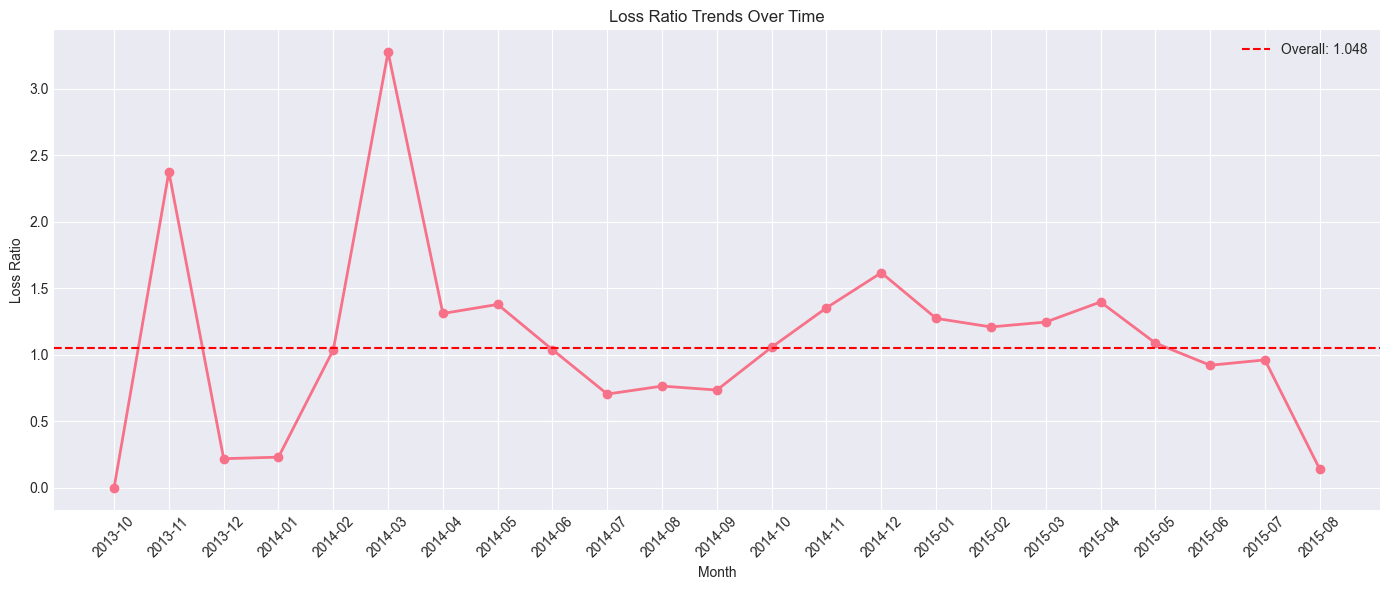

In [54]:
# Monthly trends
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).reset_index()
monthly['LossRatio'] = monthly['TotalClaims'] / monthly['TotalPremium']
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

print("MONTHLY LOSS RATIO TRENDS")
print(monthly.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['YearMonth'], monthly['LossRatio'], marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Month')
ax.set_ylabel('Loss Ratio')
ax.set_title('Loss Ratio Trends Over Time')
ax.axhline(y=overall_loss_ratio, color='red', linestyle='--', label=f'Overall: {overall_loss_ratio:.3f}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
print("DATA CLEANING")
print("=" * 50)

# Check negative values before cleaning
print(f"Negative premiums: {(df['TotalPremium'] < 0).sum()}")
print(f"Negative claims: {(df['TotalClaims'] < 0).sum()}")

# Remove negative values
df_clean = df[(df['TotalPremium'] > 0) & (df['TotalClaims'] >= 0)].copy()
print(f"\nAfter cleaning: {len(df_clean)} rows (removed {len(df) - len(df_clean)} rows)")

# Recalculate metrics
total_premium_clean = df_clean['TotalPremium'].sum()
total_claims_clean = df_clean['TotalClaims'].sum()
loss_ratio_clean = total_claims_clean / total_premium_clean

print(f"\nCLEAN PORTFOLIO METRICS:")
print(f"Total Premium: R{total_premium_clean:,.2f}")
print(f"Total Claims: R{total_claims_clean:,.2f}")
print(f"Loss Ratio: {loss_ratio_clean:.4f} ({loss_ratio_clean*100:.2f}%)")

DATA CLEANING
Negative premiums: 288
Negative claims: 5

After cleaning: 618174 rows (removed 381924 rows)

CLEAN PORTFOLIO METRICS:
Total Premium: R61,941,897.73
Total Claims: R62,090,763.77
Loss Ratio: 1.0024 (100.24%)


CORRELATION ANALYSIS
Columns for correlation: ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'CapitalOutstanding', 'CalculatedPremiumPerTerm', 'SumInsured']


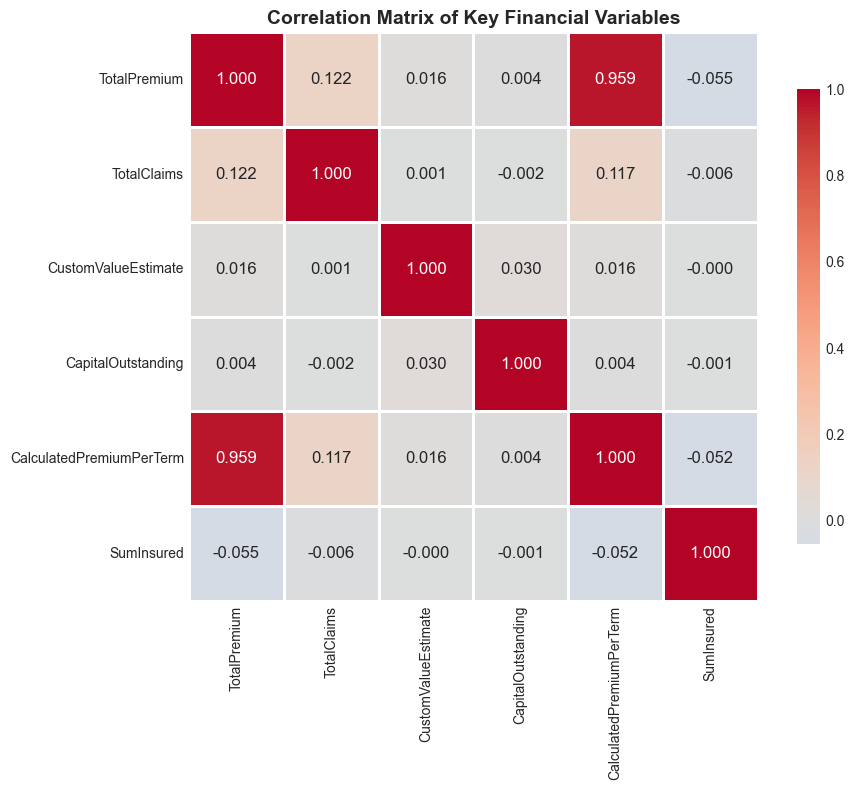


Correlation Insights:
Correlation between Premium and Claims: 0.122
  → Weak correlation - suggests other factors influence claims


In [56]:
# Correlation Matrix for Numerical Features
print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# First, ensure all numeric columns are properly converted
def clean_numeric_column(series):
    """Convert string numbers with commas to float"""
    if series.dtype == 'object':
        # Remove commas and convert to numeric
        series = series.str.replace(',', '', regex=False)
        return pd.to_numeric(series, errors='coerce')
    return series

# Apply cleaning to potential numeric columns
potential_numeric = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 
                     'CapitalOutstanding', 'CalculatedPremiumPerTerm', 'SumInsured']

for col in potential_numeric:
    if col in df_clean.columns:
        df_clean[col] = clean_numeric_column(df_clean[col])

# Select numerical columns for correlation
existing_cols = [col for col in potential_numeric if col in df_clean.columns]

print(f"Columns for correlation: {existing_cols}")

# Check if we have at least 2 columns for correlation
if len(existing_cols) >= 2:
    # Calculate correlation matrix
    corr_matrix = df_clean[existing_cols].corr()
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.3f', square=True, linewidths=1, 
                annot_kws={'size': 12}, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix of Key Financial Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print correlation insights
    print("\nCorrelation Insights:")
    if 'TotalPremium' in corr_matrix and 'TotalClaims' in corr_matrix:
        premium_claims_corr = corr_matrix.loc['TotalPremium', 'TotalClaims']
        print(f"Correlation between Premium and Claims: {premium_claims_corr:.3f}")
        if abs(premium_claims_corr) < 0.3:
            print("  → Weak correlation - suggests other factors influence claims")
else:
    print("Not enough numeric columns for correlation analysis")

OUTLIER DETECTION AND ANALYSIS
Variables for outlier analysis: ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'CapitalOutstanding', 'CalculatedPremiumPerTerm', 'SumInsured']


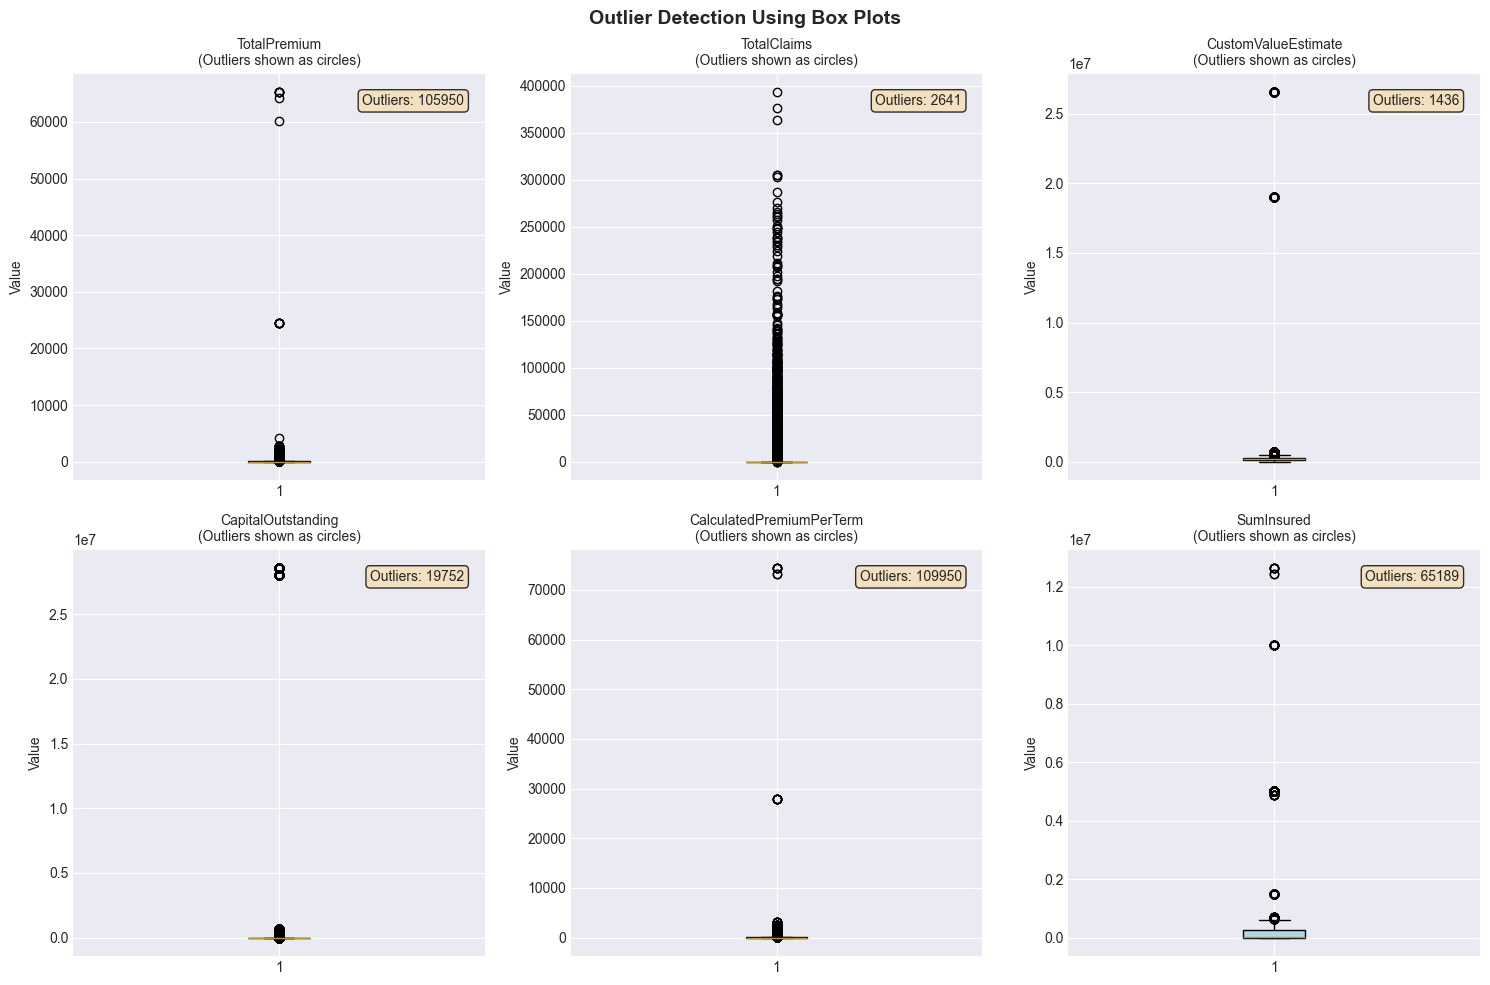

In [57]:

print("=" * 50)
print("OUTLIER DETECTION AND ANALYSIS")
print("=" * 50)

for col in ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']:
    if col in df_clean.columns and df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace(',', '', regex=False)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


fig, axes = plt.subplots(2, 3, figsize=(15, 10))


variables = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 
             'CapitalOutstanding', 'CalculatedPremiumPerTerm', 'SumInsured']

# Filter variables that exist and are numeric
existing_vars = []
for var in variables:
    if var in df_clean.columns:
        # Try to convert if needed
        if df_clean[var].dtype == 'object':
            df_clean[var] = pd.to_numeric(df_clean[var].str.replace(',', '', regex=False), errors='coerce')
        if pd.api.types.is_numeric_dtype(df_clean[var]):
            existing_vars.append(var)

print(f"Variables for outlier analysis: {existing_vars}")

for idx, var in enumerate(existing_vars):
    row = idx // 3
    col = idx % 3
    if row < 2 and col < 3:  # Ensure within bounds
        # Drop NaN for plotting
        plot_data = df_clean[var].dropna()
        if len(plot_data) > 0:
            
            axes[row, col].boxplot(plot_data, vert=True, patch_artist=True,
                                    boxprops=dict(facecolor='lightblue'))
            axes[row, col].set_title(f'{var}\n(Outliers shown as circles)', fontsize=10)
            axes[row, col].set_ylabel('Value')
            
          
            Q1 = plot_data.quantile(0.25)
            Q3 = plot_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outlier_count = ((plot_data < lower_bound) | (plot_data > upper_bound)).sum()
            axes[row, col].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                               transform=axes[row, col].transAxes, ha='right', va='top',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))


for idx in range(len(existing_vars), 6):
    row = idx // 3
    col = idx % 3
    if row < 2 and col < 3:
        axes[row, col].set_visible(False)

plt.suptitle('Outlier Detection Using Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Detailed outlier analysis
print("=" * 50)
print("OUTLIER SUMMARY STATISTICS")
print("=" * 50)

outlier_summary = []

for var in existing_vars:
    plot_data = df_clean[var].dropna()
    if len(plot_data) > 0:
        Q1 = plot_data.quantile(0.25)
        Q3 = plot_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = plot_data[(plot_data < lower_bound) | (plot_data > upper_bound)]
        outlier_pct = (len(outliers) / len(plot_data)) * 100
        
        outlier_summary.append({
            'Variable': var,
            'Lower Bound': f'{lower_bound:.2f}',
            'Upper Bound': f'{upper_bound:.2f}',
            'Outlier Count': len(outliers),
            'Outlier %': f'{outlier_pct:.2f}%'
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print(outlier_df.to_string(index=False))
else:
    print("No valid variables for outlier analysis")

OUTLIER SUMMARY STATISTICS
                Variable Lower Bound Upper Bound  Outlier Count Outlier %
            TotalPremium     -111.84      193.42         105950    17.14%
             TotalClaims        0.00        0.00           2641     0.43%
     CustomValueEstimate   -81000.00   496600.00           1436     0.92%
      CapitalOutstanding        0.00        0.00          19752    20.79%
CalculatedPremiumPerTerm     -126.86      220.12         109950    17.79%
              SumInsured  -363250.00   618750.00          65189    10.55%


In [59]:
# Quick Summary Cell
print("=" * 50)
print("EDA COMPLETE - KEY TAKEAWAYS")
print("=" * 50)

print(f"""
📊 PORTFOLIO PERFORMANCE:
   • Loss Ratio: {overall_loss_ratio*100:.1f}% (UNPROFITABLE)
   • Margin: -R{abs(overall_margin):,.2f}

📍 GEOGRAPHIC RISK:
   • HIGHEST: Gauteng (122%)
   • LOWEST: Northern Cape (28%)

🚗 VEHICLE RISK:
   • RISKIEST: SUZUKI (634% loss ratio)
   • SAFEST: CHERY, CITROEN, FORD (0 claims)

📈 TEMPORAL:
   • March 2014 anomaly: 327% loss ratio


""")

EDA COMPLETE - KEY TAKEAWAYS

📊 PORTFOLIO PERFORMANCE:
   • Loss Ratio: 104.8% (UNPROFITABLE)
   • Margin: -R2,955,983.47

📍 GEOGRAPHIC RISK:
   • HIGHEST: Gauteng (122%)
   • LOWEST: Northern Cape (28%)

🚗 VEHICLE RISK:
   • RISKIEST: SUZUKI (634% loss ratio)
   • SAFEST: CHERY, CITROEN, FORD (0 claims)

📈 TEMPORAL:
   • March 2014 anomaly: 327% loss ratio



